<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DBSCAN without Library**

In [1]:
import math
def euclidean_dist(p1 , p2):
  return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

In [2]:
def get_neighbors(points , idx , eps):
  neighbors = []

  for i in range(len(points)):
    if euclidean_dist(points[idx] , points[i]) <= eps:
      neighbors.append(i)

  return neighbors

In [7]:
def expand_cluster(points , labels , point_idx , neighbors , eps , min_pts , visited , cluster_id):
  labels[point_idx] = cluster_id

  i = 0
  while i < len(neighbors):
    neighbor_idx = neighbors[i]

    if not visited[neighbor_idx]:
      visited[neighbor_idx] = True
      new_neighbors = get_neighbors(points , neighbor_idx , eps)

      if len(new_neighbors) >= min_pts:
        neighbors += new_neighbors

      if labels[neighbor_idx] == -1:
        labels[neighbor_idx] = cluster_id

    i += 1


In [8]:
def dbscan(points , eps , min_pts):
  n = len(points)
  labels = [-1]*n
  visited = [False]*n
  cluster_id = 0

  for i in range(n):

    if visited[i]:
      continue

    visited[i] = True
    neighbors = get_neighbors(points , i , eps)

    if len(neighbors) < min_pts:
      labels[i] = -1

    else:
      cluster_id += 1
      expand_cluster(points , labels , i , neighbors , eps , min_pts , visited , cluster_id)

  return labels

In [14]:
points = [
    (1,1), (1,2), (2,2), (2,3),
    (8,7), (8,8), (9,8), (8,9),
    (25,25)
]

eps = 1.5
min_pts = 3

labels = dbscan(points, eps, min_pts)

for i, point in enumerate(points):
    print(f"Point {point} -> Cluster {labels[i]}")

Point (1, 1) -> Cluster 1
Point (1, 2) -> Cluster 1
Point (2, 2) -> Cluster 1
Point (2, 3) -> Cluster 1
Point (8, 7) -> Cluster 2
Point (8, 8) -> Cluster 2
Point (9, 8) -> Cluster 2
Point (8, 9) -> Cluster 2
Point (25, 25) -> Cluster -1


# **DBSCAN with Library**

In [17]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

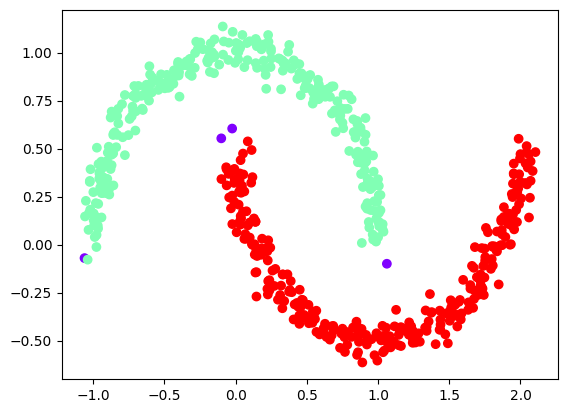

In [26]:
X, y = make_moons(n_samples=600, noise=0.05, random_state=42)
clustering = DBSCAN(eps=0.1, min_samples=4)
clustering.fit(X)
plt.scatter(X[:, 0], X[:, 1], c=clustering.labels_, cmap='rainbow')
plt.show()